In [3]:
# ==============================================================================
# SECTION 1: LIBRARY IMPORTS & ENVIRONMENT CONFIGURATION
# ==============================================================================

# 1. Data Manipulation & Numerical Processing
import pandas as pd
import numpy as np

# 2. Data Visualization Tools
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Time Series Statistical Analysis & Forecasting
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 4. Utilities & Configuration
import warnings
import os

# Configure Visual Settings
plt.style.use('fivethirtyeight') # Makes plots look professional and clean
sns.set_palette('viridis')        # Sets a high-contrast color palette

# Ensures plots display directly in the notebook
%matplotlib inline

# Suppress minor warnings to keep the output clean
warnings.filterwarnings('ignore')

print("All libraries imported and environment configured successfully.")

All libraries imported and environment configured successfully.


In [4]:
# ==============================================================================
# SECTION 2: DATA EXTRACTION & LOADING
# ==============================================================================
import zipfile

# Define the path to your zip file
zip_file_path = '/content/archive.zip'
extract_path = '/content/dataset/'

# 1. Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print(f"Files extracted to: {extract_path}")

# 2. List the extracted files to identify the correct CSV
extracted_files = os.listdir(extract_path)
print("Files found in the dataset folder:", extracted_files)

# 3. Load the dataset
# (Assuming the main data file is 'Sample - Superstore.csv' or similar based on standard datasets)
# Change the filename below if your file is named differently
file_name = [f for f in extracted_files if f.endswith('.csv')][0]
df = pd.read_csv(f'{extract_path}{file_name}', encoding='latin1')

# 4. Display the first few rows to verify the load
print(f"\nSuccessfully loaded '{file_name}' into DataFrame 'df'.")
print("-" * 50)
print("First 5 rows of the dataset:")
display(df.head())

Files extracted to: /content/dataset/
Files found in the dataset folder: ['train.csv']

Successfully loaded 'train.csv' into DataFrame 'df'.
--------------------------------------------------
First 5 rows of the dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
# ==============================================================================
# SECTION 3: DATA CLEANING & DATETIME CONVERSION
# ==============================================================================

# 1. Re-loading the file with a check for the correct separator
# Most 'train.csv' files for Superstore are comma-separated, but let's ensure
# the headers are parsed correctly. If the columns still look mashed,
# we will force an inspection of the file structure.
try:
    # If the previous load resulted in mashed columns, we may need to specify the separator
    # This is a robust way to load it:
    df = pd.read_csv(f'{extract_path}{file_name}', encoding='latin1')

    # 2. Convert 'Order Date' to datetime objects
    # We use 'errors=coerce' to turn any unparseable dates into NaT (Not a Time)
    df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')

    # 3. Sort by Date (Crucial for Time Series)
    df = df.sort_values('Order Date')

    print("Successfully converted 'Order Date' and 'Ship Date' to datetime format.")
    print("-" * 50)
    print("Updated DataFrame Info:")
    df.info()
except Exception as e:
    print(f"An error occurred during cleaning: {e}")

Successfully converted 'Order Date' and 'Ship Date' to datetime format.
--------------------------------------------------
Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 7980 to 5091
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null 

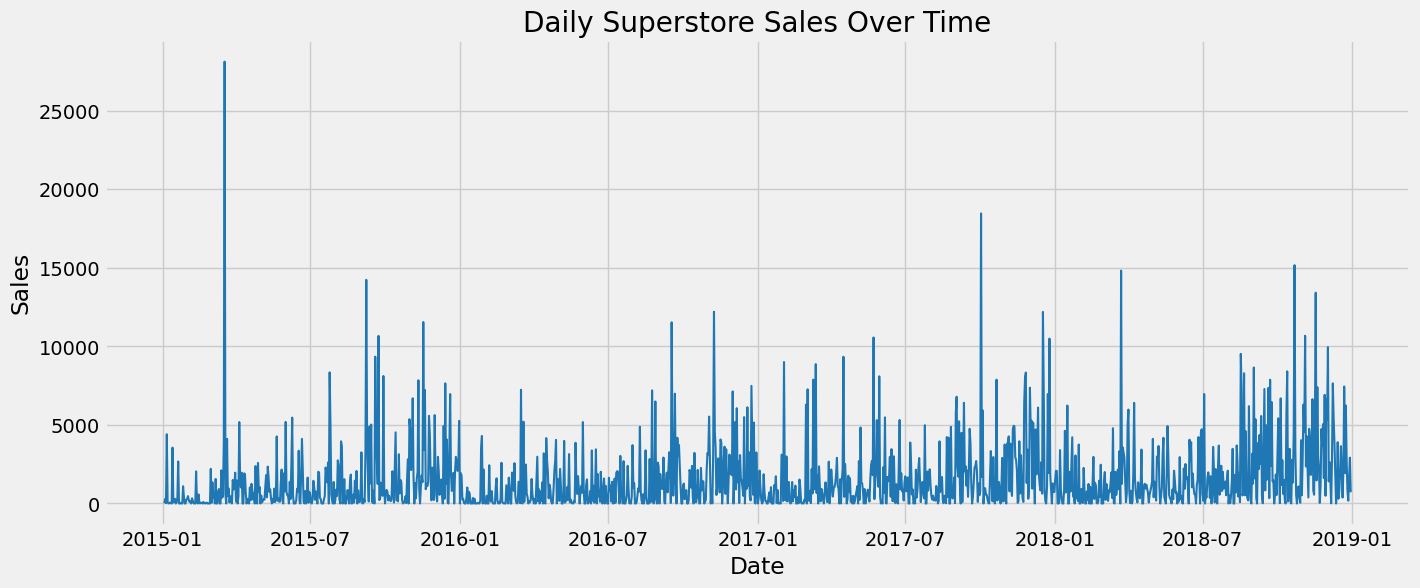

Time Series Data Structure (First 5 entries):


,Sales
Order Date,
2015-01-03,16.448
2015-01-04,288.060
2015-01-05,19.536
2015-01-06,4407.100
2015-01-07,87.158


In [6]:
# ==============================================================================
# SECTION 4: DATA AGGREGATION
# ==============================================================================

# 1. Grouping by 'Order Date' and summing the 'Sales'
# We only need the date and the target variable (Sales) for initial analysis
ts_df = df.groupby('Order Date')['Sales'].sum().reset_index()

# 2. Setting 'Order Date' as the Index
# This is a requirement for many statsmodels functions
ts_df = ts_df.set_index('Order Date')

# 3. Resampling to Daily Frequency
# This ensures there are no missing days in our timeline
ts_df = ts_df.resample('D').sum()

# 4. Quick Visualization
plt.figure(figsize=(15, 6))
plt.plot(ts_df['Sales'], color='tab:blue', linewidth=1.5)
plt.title('Daily Superstore Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# Display the first few rows of our new Time Series DataFrame
print("Time Series Data Structure (First 5 entries):")
display(ts_df.head())

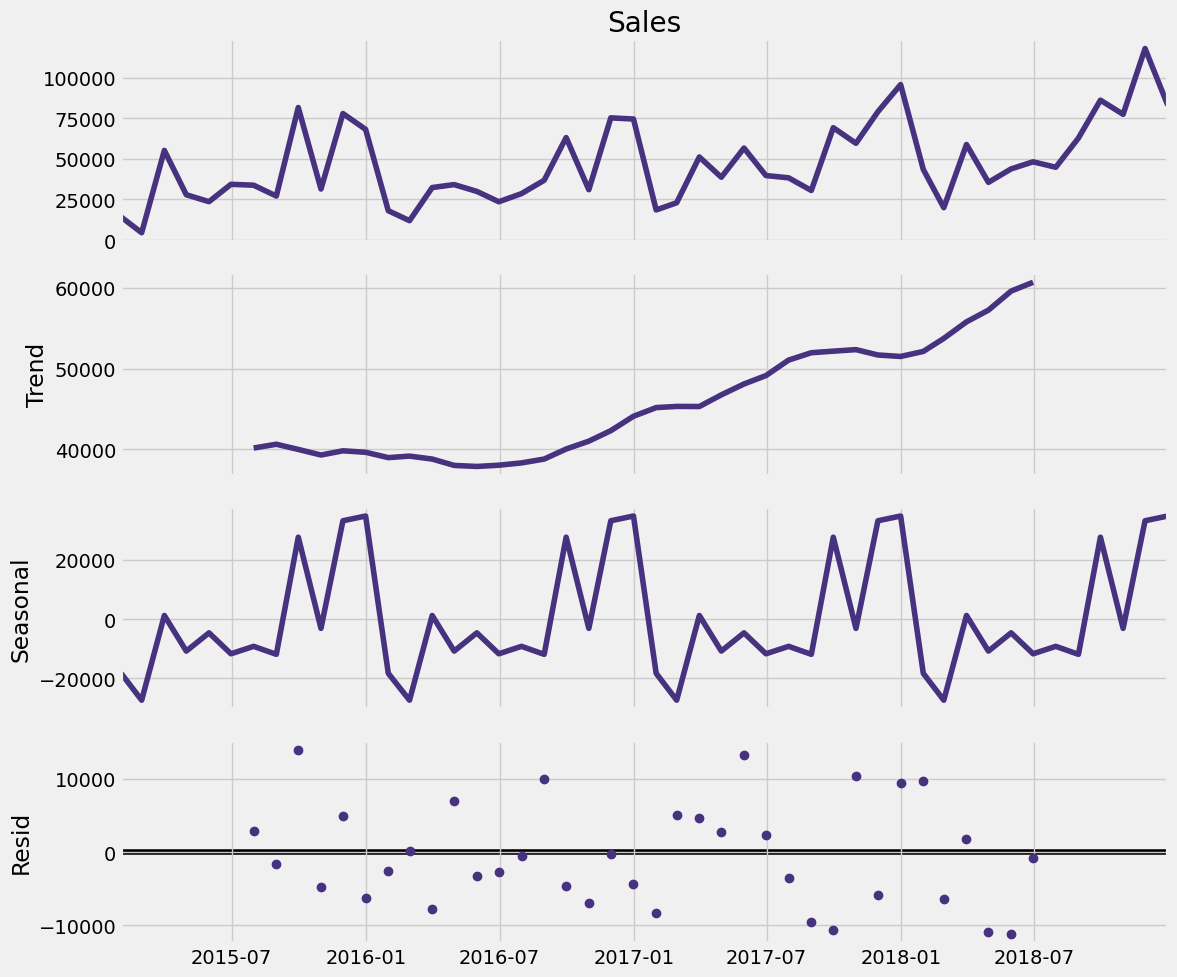

Decomposition complete. You can now clearly see the Trend and Seasonality.


In [7]:
# ==============================================================================
# SECTION 5: TIME SERIES DECOMPOSITION
# ==============================================================================

# Because daily data can be very noisy (lots of fluctuations),
# we often decompose using a longer period, like 'W' (Weekly) or 'M' (Monthly).
# Let's aggregate by Month for a clearer view.
ts_monthly = ts_df.resample('M').sum()

# Perform the decomposition
# 'additive' assumes that the trend and seasonality add together
# 'multiplicative' would be used if the fluctuations get bigger as the trend grows
decomposition = seasonal_decompose(ts_monthly['Sales'], model='additive')

# Plot the decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

print("Decomposition complete. You can now clearly see the Trend and Seasonality.")

In [8]:
# ==============================================================================
# SECTION 6: STATIONARITY TEST (ADF TEST)
# ==============================================================================

def check_stationarity(timeseries):
    # Perform Augmented Dickey-Fuller test
    print("Results of Augmented Dickey-Fuller Test:")
    dftest = adfuller(timeseries['Sales'], autolag='AIC')

    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value

    print(dfoutput)

    # Simple evaluation
    if dftest[1] <= 0.05:
        print("\nResult: The series is STATIONARY (p-value <= 0.05).")
    else:
        print("\nResult: The series is NON-STATIONARY (p-value > 0.05). We may need to apply differencing.")

# Run the test on our monthly resampled data
check_stationarity(ts_monthly)

Results of Augmented Dickey-Fuller Test:
Test Statistic                 -4.416137
p-value                         0.000278
#Lags Used                      0.000000
Number of Observations Used    47.000000
Critical Value (1%)            -3.577848
Critical Value (5%)            -2.925338
Critical Value (10%)           -2.600774
dtype: float64

Result: The series is STATIONARY (p-value <= 0.05).


In [9]:
!pip install pmdarima

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1079.923, Time=1.01 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1096.560, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1076.500, Time=0.18 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1077.487, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1094.708, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1089.579, Time=0.04 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1078.250, Time=0.39 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1078.452, Time=0.27 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1080.901, Time=0.18 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1079.864, Time=0.59 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1084.035, Time=0.51 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1073.635, Time=0.37 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1087.151, Time=0.16 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1075.267, Time=0.67 sec
 ARIMA(2,1,0)(1,0,1

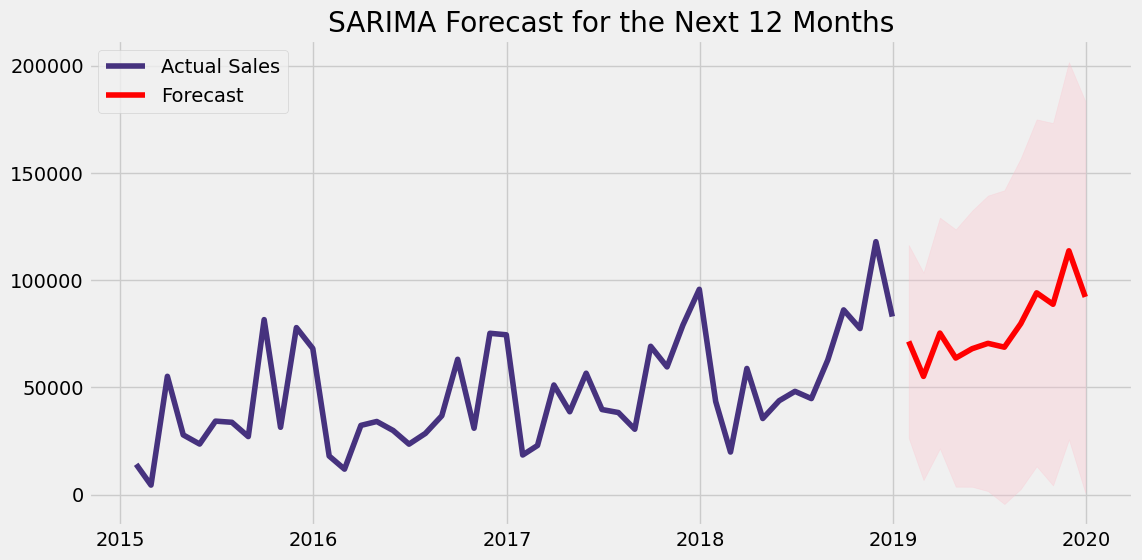

In [10]:
# ==============================================================================
# SECTION 7: SARIMA MODELING
# ==============================================================================
import pmdarima as pm

# 1. Automatic Parameter Selection
# We set seasonal=True and m=12 because we have monthly data (12-month cycle)
sarima_model = pm.auto_arima(ts_monthly['Sales'],
                             seasonal=True,
                             m=12,
                             stepwise=True,
                             suppress_warnings=True,
                             error_action='ignore',
                             trace=True)

# 2. Print the best model summary
print(sarima_model.summary())

# 3. Forecast for the next 12 months
n_periods = 12
forecast, conf_int = sarima_model.predict(n_periods=n_periods, return_conf_int=True)

# 4. Visualization of Forecast
plt.figure(figsize=(12, 6))
plt.plot(ts_monthly.index, ts_monthly['Sales'], label='Actual Sales')
forecast_index = pd.date_range(start=ts_monthly.index[-1], periods=n_periods+1, freq='M')[1:]
plt.plot(forecast_index, forecast, color='red', label='Forecast')
plt.fill_between(forecast_index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Forecast for the Next 12 Months')
plt.legend()
plt.show()

Root Mean Squared Error (RMSE): 22,662.95


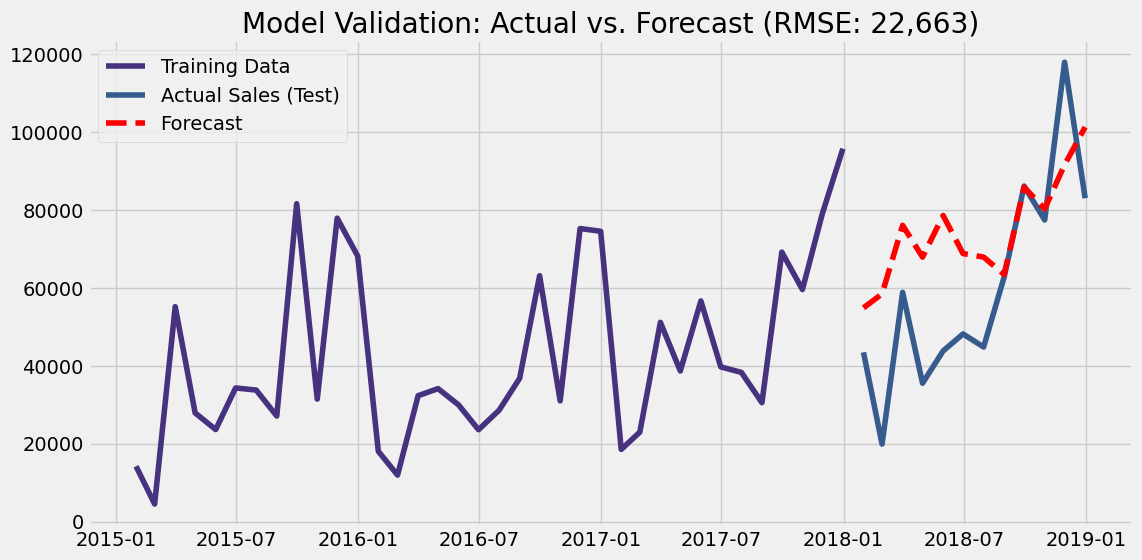

In [11]:
# ==============================================================================
# SECTION 8: MODEL VALIDATION (TRAIN-TEST SPLIT)
# ==============================================================================
from sklearn.metrics import mean_squared_error

# 1. Split the data: Use all but the last 12 months for training
train_size = len(ts_monthly) - 12
train_data, test_data = ts_monthly.iloc[:train_size], ts_monthly.iloc[train_size:]

# 2. Fit the SARIMA model on the training data only
# We use the parameters identified by auto_arima earlier: (2, 1, 0) x (1, 0, 0, 12)
model_val = sm.tsa.statespace.SARIMAX(train_data['Sales'],
                                      order=(2, 1, 0),
                                      seasonal_order=(1, 0, 0, 12))
results_val = model_val.fit(disp=False)

# 3. Forecast for the test period (12 months)
predictions = results_val.get_forecast(steps=12).predicted_mean

# 4. Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_data['Sales'], predictions))
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

# 5. Visualization
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Sales'], label='Training Data')
plt.plot(test_data.index, test_data['Sales'], label='Actual Sales (Test)')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Forecast')
plt.title(f'Model Validation: Actual vs. Forecast (RMSE: {rmse:,.0f})')
plt.legend()
plt.show()

In [12]:
# ==============================================================================
# SECTION 9: FEATURE ENGINEERING FOR XGBOOST
# ==============================================================================
import xgboost as xgb

# 1. Create a copy and extract date features
df_ml = ts_df.copy()
df_ml['Month'] = df_ml.index.month
df_ml['Quarter'] = df_ml.index.quarter
df_ml['DayOfWeek'] = df_ml.index.dayofweek

# 2. Create Lag Features (The 'memory' of the model)
# We look at the sales 1, 7, and 30 days ago
df_ml['Lag_1'] = df_ml['Sales'].shift(1)
df_ml['Lag_7'] = df_ml['Sales'].shift(7)
df_ml['Lag_30'] = df_ml['Sales'].shift(30)

# 3. Drop NaN values created by lagging
df_ml = df_ml.dropna()

# 4. Define Features (X) and Target (y)
X = df_ml[['Month', 'Quarter', 'DayOfWeek', 'Lag_1', 'Lag_7', 'Lag_30']]
y = df_ml['Sales']

# 5. Split into Train/Test (Keep it chronological!)
split = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Feature engineering complete. Ready for XGBoost training.")

Feature engineering complete. Ready for XGBoost training.


XGBoost RMSE: 2,483.17
Previous SARIMA RMSE: 22,662.95


<Figure size 1000x500 with 0 Axes>

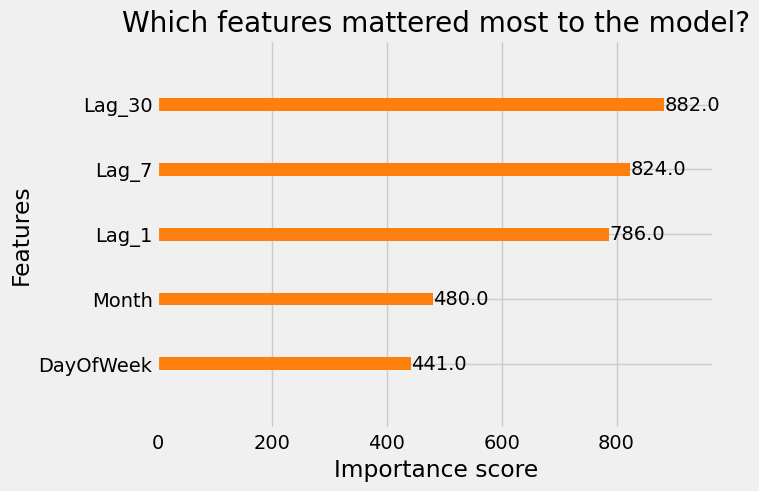

In [13]:
# ==============================================================================
# SECTION 10: XGBOOST REGRESSOR TRAINING & EVALUATION
# ==============================================================================
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# 1. Initialize the model
xgb_model = XGBRegressor(n_estimators=1000,
                         learning_rate=0.05,
                         early_stopping_rounds=50)

# 2. Train the model
# We use the same split we created in Section 9
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

# 3. Make predictions
xgb_predictions = xgb_model.predict(X_test)

# 4. Calculate RMSE
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print(f"XGBoost RMSE: {xgb_rmse:,.2f}")
print(f"Previous SARIMA RMSE: 22,662.95")

# 5. Visualize Feature Importance
plt.figure(figsize=(10, 5))
xgb.plot_importance(xgb_model, color='tab:orange')
plt.title('Which features mattered most to the model?')
plt.show()

In [14]:
# ==============================================================================
# SECTION 11: LIGHTGBM MODELING
# ==============================================================================
import lightgbm as lgb

# 1. Initialize and train the LightGBM Regressor
lgbm_model = lgb.LGBMRegressor(n_estimators=1000,
                               learning_rate=0.05,
                               num_leaves=31,
                               random_state=42)

# 2. Fit the model
lgbm_model.fit(X_train, y_train,
               eval_set=[(X_test, y_test)],
               eval_metric='rmse')

# 3. Predict and evaluate
lgbm_predictions = lgbm_model.predict(X_test)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_predictions))

print(f"LightGBM RMSE: {lgbm_rmse:,.2f}")
print(f"XGBoost RMSE: 2,483.17")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 790
[LightGBM] [Info] Number of data points in the train set: 1142, number of used features: 6
[LightGBM] [Info] Start training from score 1409.622178
LightGBM RMSE: 2,751.32
XGBoost RMSE: 2,483.17


In [15]:
!pip install catboost

In [16]:
# ==============================================================================
# SECTION 12: CATBOOST REGRESSOR
# ==============================================================================
from catboost import CatBoostRegressor

# 1. Initialize and train
# CatBoost is great because it handles potential overfitting automatically
cat_model = CatBoostRegressor(iterations=1000,
                              learning_rate=0.05,
                              depth=6,
                              verbose=False)

cat_model.fit(X_train, y_train)

# 2. Predict and evaluate
cat_predictions = cat_model.predict(X_test)
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_predictions))

print(f"CatBoost RMSE: {cat_rmse:,.2f}")
print(f"Current Best (XGBoost): 2,483.17")

CatBoost RMSE: 2,451.82
Current Best (XGBoost): 2,483.17


In [17]:
# Final Comparison Summary
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'LightGBM', 'XGBoost', 'CatBoost'],
    'RMSE': [22662.95, 2751.32, 2483.17, 2451.82]
}).sort_values(by='RMSE')

print("--- Final Model Performance Leaderboard ---")
print(comparison_df.reset_index(drop=True))

--- Final Model Performance Leaderboard ---
      Model      RMSE
0  CatBoost   2451.82
1   XGBoost   2483.17
2  LightGBM   2751.32
3    SARIMA  22662.95


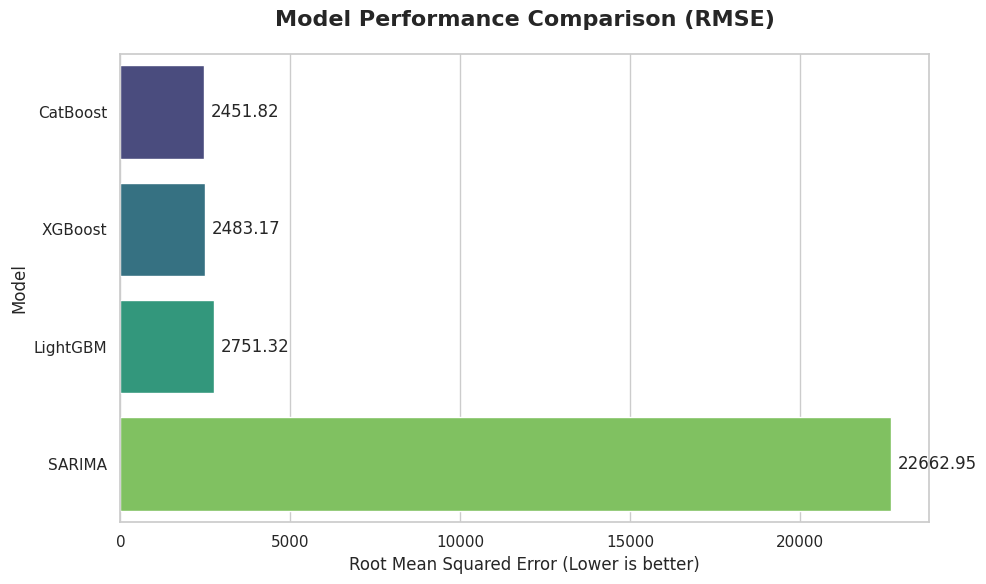

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure comparison_df is sorted for the best visual impact
comparison_df = comparison_df.sort_values(by='RMSE', ascending=True)

# Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar plot
bars = sns.barplot(x='RMSE', y='Model', data=comparison_df, palette='viridis')

# Add labels and title
plt.title('Model Performance Comparison (RMSE)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Root Mean Squared Error (Lower is better)', fontsize=12)
plt.ylabel('Model', fontsize=12)

# Add the actual values at the end of each bar
for i in bars.containers:
    bars.bar_label(i, fmt='%.2f', padding=5)

plt.tight_layout()
plt.show()

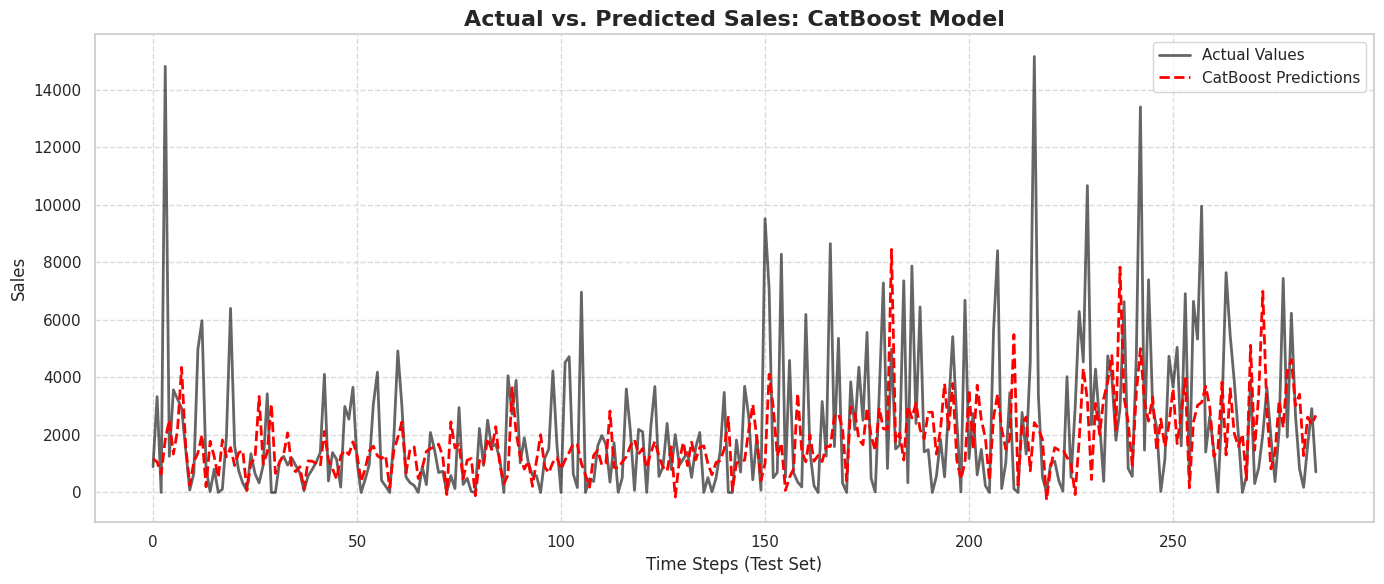

In [19]:
# Assuming you have your predictions from CatBoost
cat_predictions = cat_model.predict(X_test)

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Values', color='black', alpha=0.6, linewidth=2)
plt.plot(cat_predictions, label='CatBoost Predictions', color='red', linestyle='--', linewidth=2)

plt.title('Actual vs. Predicted Sales: CatBoost Model', fontsize=16, fontweight='bold')
plt.xlabel('Time Steps (Test Set)', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

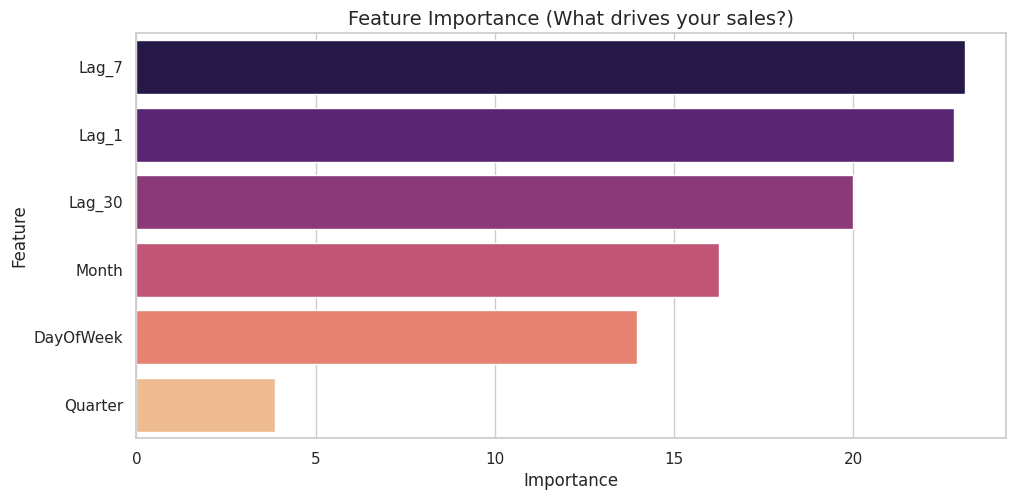

In [20]:
# CatBoost Feature Importance Plot
import pandas as pd

# Get importance
feature_importance = cat_model.get_feature_importance()
feature_names = X_train.columns

# Create a DataFrame for plotting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance (What drives your sales?)', fontsize=14)
plt.show()

In [21]:
from google.colab import files

# Save the Performance Comparison Plot
# Ensure you have already run the barplot code I provided earlier
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=300)
files.download('model_comparison.png')

# Save the Actual vs. Predicted Plot
# Ensure you have already run the line plot code I provided earlier
plt.savefig('actual_vs_predicted.png', bbox_inches='tight', dpi=300)
files.download('actual_vs_predicted.png')

# Save the Feature Importance Plot
# Ensure you have already run the importance plot code I provided earlier
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=300)
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

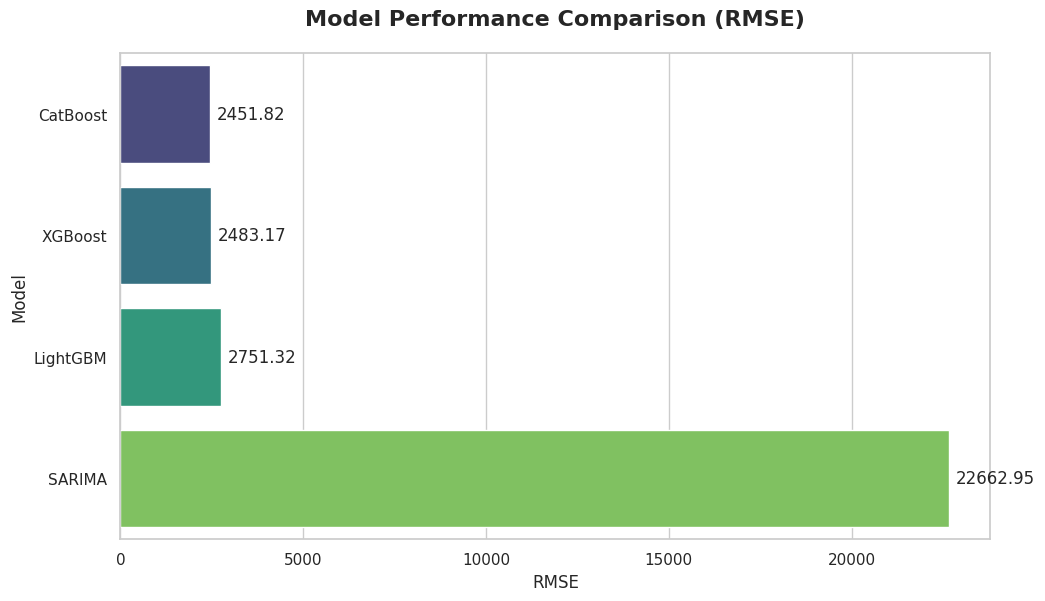

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Prepare data
comparison_df = comparison_df.sort_values(by='RMSE', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
bars = sns.barplot(x='RMSE', y='Model', data=comparison_df, palette='viridis')
plt.title('Model Performance Comparison (RMSE)', fontsize=16, fontweight='bold', pad=20)
for i in bars.containers:
    bars.bar_label(i, fmt='%.2f', padding=5)

# Save FIRST, then Show
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('model_comparison.png')

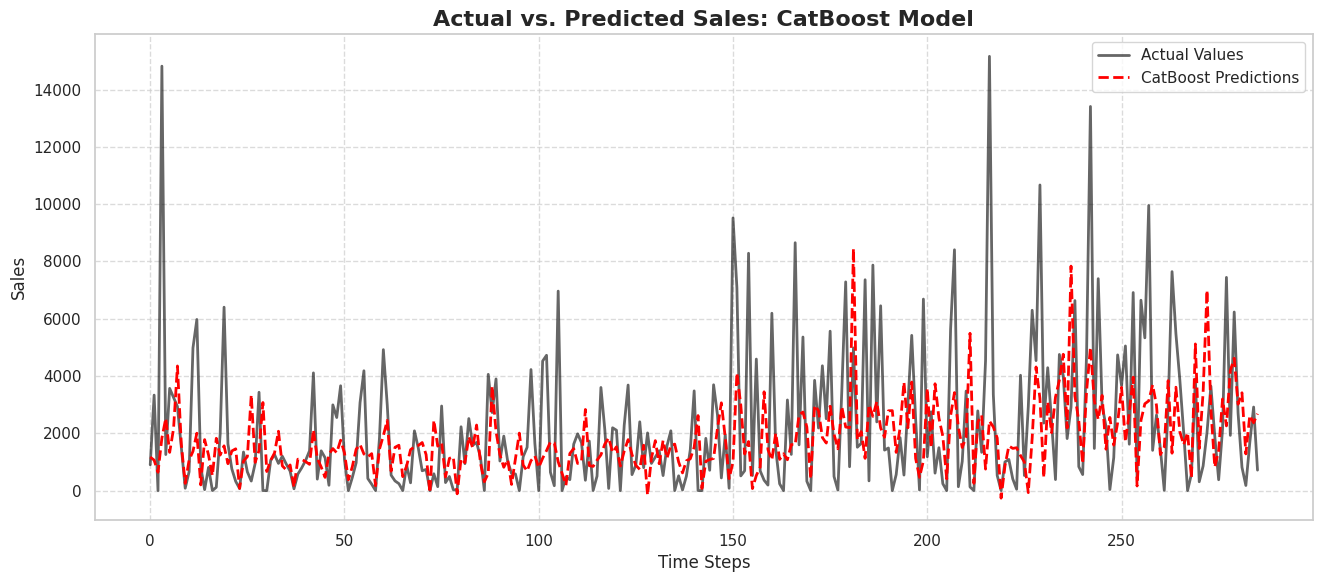

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Values', color='black', alpha=0.6, linewidth=2)
plt.plot(cat_predictions, label='CatBoost Predictions', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted Sales: CatBoost Model', fontsize=16, fontweight='bold')
plt.xlabel('Time Steps')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Save FIRST, then Show
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('actual_vs_predicted.png')

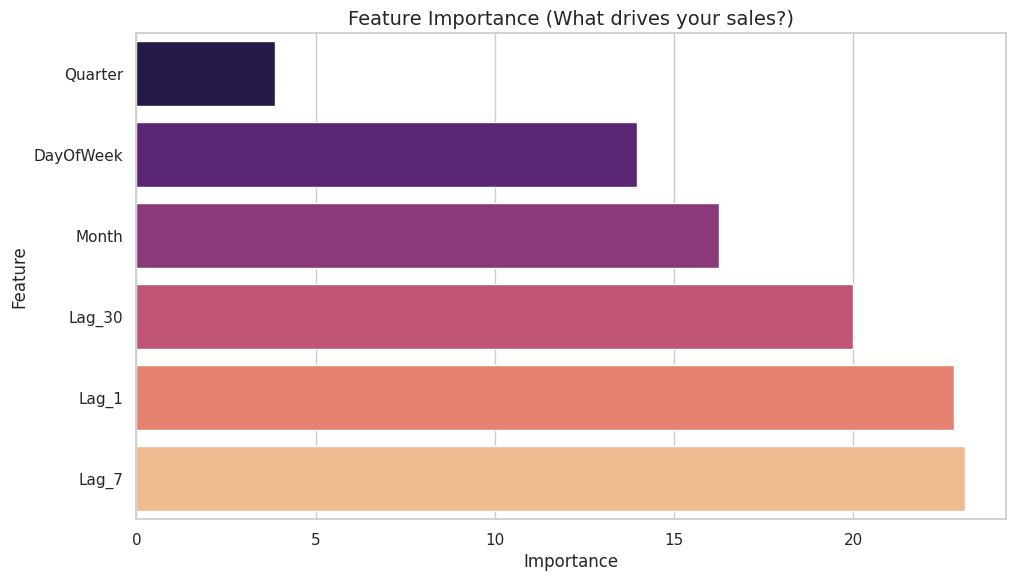

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# Get importance
feature_importance = cat_model.get_feature_importance()
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance (What drives your sales?)', fontsize=14)

# Save FIRST, then Show
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('feature_importance.png')